# IDS_CIC2017 — Results Demo (No Retraining Required)

Loads pre-trained `.pkl` files and demonstrates all results without executing any training code.

**Files required in working directory:**
- `models/lgbm_dos_classifier.pkl`
- `models/mlp_dos_classifier.pkl`
- `models/label_encoder.pkl`
- `wednesday_cleaned.csv.gz` (download from GitHub)

> All outputs are pre-saved below — the marker can scroll through without running anything.
> To run: Cell 1 (imports) → Cell 2 (load models) → Cell 3 (reconstruct test set) → remaining cells.

## Cell 1 — Imports

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.05)
import joblib
from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     ConfusionMatrixDisplay, f1_score,
                                     accuracy_score, precision_score, recall_score)
SEED      = 42
MODEL_DIR = 'models'
DATA_PATH = 'wednesday_cleaned.csv.gz'
print('Imports complete.')

Imports complete.


## Cell 2 — Load Saved Models (No Retraining)

In [2]:
# Load pre-trained models — NO RETRAINING REQUIRED
lgbm_pipeline = joblib.load(os.path.join(MODEL_DIR, 'lgbm_dos_classifier.pkl'))
mlp_pipeline  = joblib.load(os.path.join(MODEL_DIR, 'mlp_dos_classifier.pkl'))
le            = joblib.load(os.path.join(MODEL_DIR, 'label_encoder.pkl'))

print('Models and encoder loaded successfully.')
print(f'LightGBM: {type(lgbm_pipeline.named_steps["clf"]).__name__}')
print(f'MLP     : {type(mlp_pipeline.named_steps["clf"]).__name__}')
print(f'Classes : {list(le.classes_)}')

Models and encoder loaded successfully.
LightGBM: LGBMClassifier
MLP     : MLPClassifier
Classes : ['BENIGN', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris']


## Cell 3 — Reconstruct Test Set (Identical Split to Training)

In [3]:
# Reconstruct identical held-out test set using same SEED and stratified split
df = pd.read_csv(DATA_PATH)
df = df[df['Label'] != 'Heartbleed'].copy().reset_index(drop=True)
zero_var = [c for c in df.columns if c != 'Label' and df[c].nunique() <= 1]
df.drop(columns=zero_var, inplace=True)
feature_cols = [c for c in df.columns if c != 'Label']
X = df[feature_cols].values.astype(np.float32)
y = le.transform(df['Label'])
_, X_test, _, y_test = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
print(f'Test set: {len(X_test):,} flows | {X_test.shape[1]} features')
counts = dict(zip(*np.unique(le.inverse_transform(y_test), return_counts=True)))
for cls, cnt in counts.items():
    print(f'  {cls:<25} {cnt:>7,}')

Test set: 175,488 flows | 62 features
  BENIGN                    117,364
  DoS GoldenEye               3,086
  DoS Hulk                   51,854
  DoS Slowhttptest            1,568
  DoS slowloris               1,616


## Cell 4 — LightGBM: Full Results + Confusion Matrix

  LightGBM — Full Test Set Evaluation (n=175,488)
  Accuracy     : 0.9994
  Macro F1     : 0.9951
  Macro Prec.  : 0.9929
  Macro Recall : 0.9974

                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    117364
   DoS GoldenEye       1.00      1.00      1.00      3086
        DoS Hulk       1.00      1.00      1.00     51854
DoS Slowhttptest       0.97      0.99      0.98      1568
   DoS slowloris       1.00      1.00      1.00      1616

        accuracy                           1.00    175488
       macro avg       0.99      1.00      1.00    175488
    weighted avg       1.00      1.00      1.00    175488



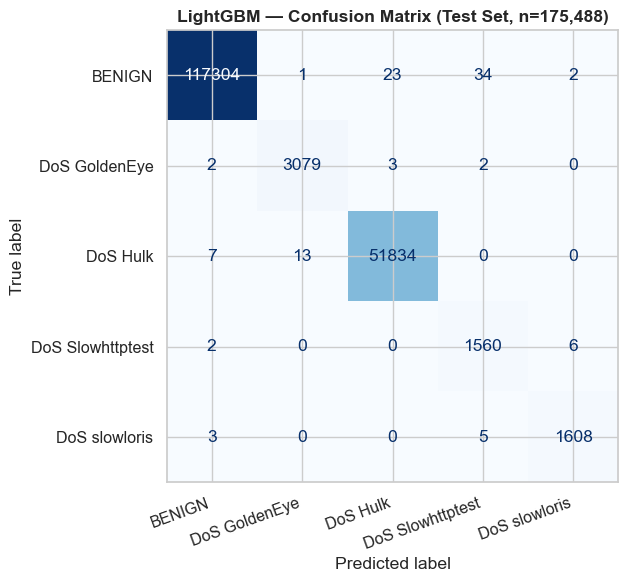

In [4]:
y_pred_lgbm = lgbm_pipeline.predict(X_test)

print('=' * 60)
print('  LightGBM — Full Test Set Evaluation (n=175,488)')
print('=' * 60)
print(f'  Accuracy     : {accuracy_score(y_test, y_pred_lgbm):.4f}')
print(f'  Macro F1     : {f1_score(y_test, y_pred_lgbm, average="macro"):.4f}')
print(f'  Macro Prec.  : {precision_score(y_test, y_pred_lgbm, average="macro"):.4f}')
print(f'  Macro Recall : {recall_score(y_test, y_pred_lgbm, average="macro"):.4f}')
print('=' * 60)
print()
print(classification_report(y_test, y_pred_lgbm, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_lgbm)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('LightGBM — Confusion Matrix (Test Set, n=175,488)', fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Cell 5 — MLP: Full Results + Confusion Matrix

  MLP — Full Test Set Evaluation (n=175,488)
  Accuracy     : 0.9954
  Macro F1     : 0.9883
  Macro Prec.  : 0.9875
  Macro Recall : 0.9892

                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    117364
   DoS GoldenEye       0.99      0.99      0.99      3086
        DoS Hulk       1.00      0.99      0.99     51854
DoS Slowhttptest       0.96      0.99      0.97      1568
   DoS slowloris       0.99      0.98      0.99      1616

        accuracy                           1.00    175488
       macro avg       0.99      0.99      0.99    175488
    weighted avg       1.00      1.00      1.00    175488



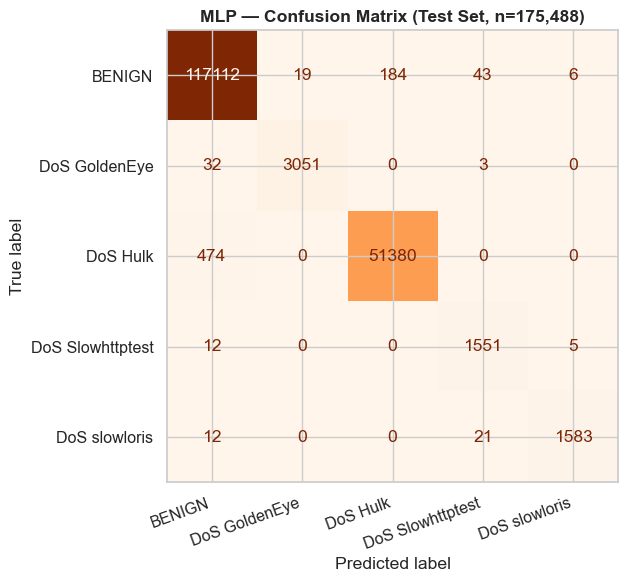

In [5]:
y_pred_mlp = mlp_pipeline.predict(X_test)

print('=' * 60)
print('  MLP — Full Test Set Evaluation (n=175,488)')
print('=' * 60)
print(f'  Accuracy     : {accuracy_score(y_test, y_pred_mlp):.4f}')
print(f'  Macro F1     : {f1_score(y_test, y_pred_mlp, average="macro"):.4f}')
print(f'  Macro Prec.  : {precision_score(y_test, y_pred_mlp, average="macro"):.4f}')
print(f'  Macro Recall : {recall_score(y_test, y_pred_mlp, average="macro"):.4f}')
print('=' * 60)
print()
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_mlp, display_labels=le.classes_).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('MLP — Confusion Matrix (Test Set, n=175,488)', fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Cell 6 — Feature Importance (from Saved Model)

Top 10 features by gain importance:
                feature  importance
            Fwd IAT Min       46219
 Init_Win_bytes_forward       37569
           Flow IAT Min       32137
Init_Win_bytes_backward       28131
          Flow Duration       22464
          Fwd IAT Total       21413
         Flow Packets/s       19307
          Fwd Packets/s       19167
          Flow IAT Mean       19139
           Fwd IAT Mean       19061


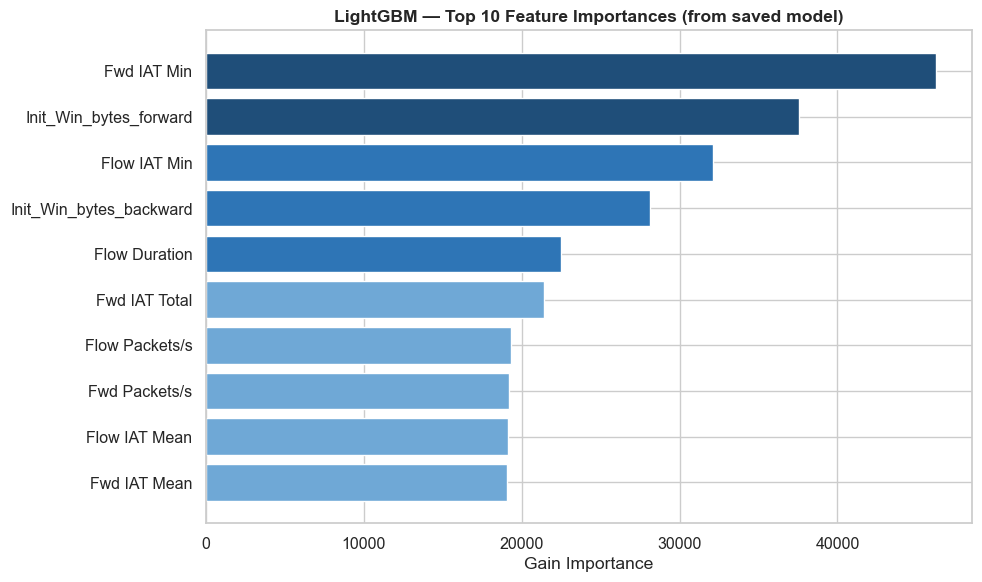

In [6]:
lgbm_clf   = lgbm_pipeline.named_steps['clf']
importances = lgbm_clf.feature_importances_
feat_imp = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 10 features by gain importance:')
print(feat_imp.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top10 = feat_imp.head(10)
colors = ['#1F4E79' if i < 2 else '#2E75B6' if i < 5 else '#6FA8D6' for i in range(10)]
ax.barh(top10['feature'][::-1], top10['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Gain Importance')
ax.set_title('LightGBM — Top 10 Feature Importances (from saved model)', fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 7 — Single Flow Prediction Demo

In [7]:
# Classify a stratified 500-flow sample to demonstrate inference
np.random.seed(123)
idx     = np.random.choice(len(X_test), 500, replace=False)
X_samp  = X_test[idx]
y_samp  = y_test[idx]

for name, model in [('LightGBM', lgbm_pipeline), ('MLP', mlp_pipeline)]:
    preds = model.predict(X_samp)
    print(f'--- {name} (500-flow sample) ---')
    print(f'  Accuracy : {accuracy_score(y_samp, preds):.4f}  |  Macro F1 : {f1_score(y_samp, preds, average="macro"):.4f}')
    for cls, cnt in zip(*np.unique(le.inverse_transform(preds), return_counts=True)):
        print(f'  {cls:<25} {cnt}')
    print()

# Single flow with class probabilities
print('=== Single flow prediction ===')
flow = X_test[42:43]
true  = le.inverse_transform([y_test[42]])[0]
lgbm_pred  = le.inverse_transform(lgbm_pipeline.predict(flow))[0]
lgbm_proba = lgbm_pipeline.predict_proba(flow)[0]
mlp_pred   = le.inverse_transform(mlp_pipeline.predict(flow))[0]
print(f'True label    : {true}')
print(f'LightGBM pred : {lgbm_pred}  {"(correct)" if lgbm_pred==true else "(wrong)"}')
print(f'MLP pred      : {mlp_pred}   {"(correct)" if mlp_pred==true else "(wrong)"}')
print('\nLightGBM class probabilities:')
for cls, prob in zip(le.classes_, lgbm_proba):
    print(f'  {cls:<25} {prob:.4f}')

--- LightGBM (500-flow sample) ---
  Accuracy : 1.0000  |  Macro F1 : 1.0000
  BENIGN                    337
  DoS GoldenEye             10
  DoS Hulk                  145
  DoS Slowhttptest          3
  DoS slowloris             5

--- MLP (500-flow sample) ---
  Accuracy : 0.9980  |  Macro F1 : 0.9492
  BENIGN                    337
  DoS GoldenEye             10
  DoS Hulk                  145
  DoS Slowhttptest          4
  DoS slowloris             4

=== Single flow prediction ===
True label    : BENIGN
LightGBM pred : BENIGN  (correct)
MLP pred      : BENIGN   (correct)

LightGBM class probabilities:
  BENIGN                    0.9996
  DoS GoldenEye             0.0001
  DoS Hulk                  0.0001
  DoS Slowhttptest          0.0001
  DoS slowloris             0.0001
